# Objetivo A — Métricas Custom para Reducción de Falsos Positivos
## Proyecto PLUS TI – Universidad del Valle 2025

**Estructura del notebook (v2):**
1. Setup y carga de datos
2. Selección de features e ingeniería
3. Split temporal + undersampling
4. Parámetros base y datasets LightGBM
5. Funciones auxiliares de evaluación
6. **Paso 4 — Punto común (todos los grupos):** reducir FP ratio con recall ≥ 90%
   - `feval_fp_ratio` — penalización directa de FP
   - `feval_balanced` — balance recall / FP ratio
7. **Paso 6 — Objetivo del grupo:** maximizar monto salvado en USD
   - `feval_high_value_precision` — recall en fraudes del percentil 75+
   - `feval_economic_utility` — utilidad económica: monto salvado − costo FP
   - `feval_amount_fbeta_adaptive` — F-beta con pesos cuadráticos por monto
8. Comparativa separada: Paso 4 vs Paso 6
9. Conclusión y selección de función

> **Nota metodológica:** los modelos del Paso 4 se evalúan con threshold que garantiza
> recall ≥ 90% (criterio del enunciado §4-5). Los modelos del Paso 6 se evalúan con
> el threshold que maximiza la utilidad económica (monto_TP − costo_FP), sin restricción
> de recall, dado que el objetivo asignado es maximizar monto salvado (§6).

## 0. Setup e imports

In [ ]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, precision_recall_curve
)
from sklearn.utils import resample

SEED = 22
np.random.seed(SEED)
print('LightGBM version:', lgb.__version__)

LightGBM version: 4.6.0


## 0.1 Configuración GPU

In [ ]:
import subprocess

def check_gpu():
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            print('✓ GPU detectada')
            for line in result.stdout.split('\n'):
                if any(x in line for x in ['Tesla','T4','A100','V100','RTX','GTX']):
                    print(' ', line.strip())
            return True
        print('✗ No se detectó GPU'); return False
    except FileNotFoundError:
        print('✗ nvidia-smi no encontrado'); return False

GPU_AVAILABLE = check_gpu()
GPU_PARAMS = {'device':'gpu','gpu_platform_id':0,'gpu_device_id':0} if GPU_AVAILABLE else {}
print('\nGPU_PARAMS:', GPU_PARAMS if GPU_PARAMS else 'CPU mode')

✓ GPU detectada
  |   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

GPU_PARAMS: {'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0}


## 1. Carga del dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
PATH_OUTPUTS  = PATH_PROJECT + 'models/modelo_a'
os.makedirs(PATH_OUTPUTS, exist_ok=True)

FILE = 'bo_vip_clean.csv'
df = pd.read_csv(PATH_DATASETS + FILE, parse_dates=['datetime_tx'])
print(f'Shape: {df.shape}')
print(f'Fraude: {df["is_fraud"].mean():.2%}')
df.head(3)

Mounted at /content/drive
Shape: (100003, 50)
Fraude: 4.92%


,datetime_tx,bank_code,bank_name,bank_country,bank_tier,client_segment,channel,card_brand,MTI,DE3_processing_code,...,approved,response_description,client_baseline_amount,client_home_city,is_fraud,month,time_since_last_txn_min,txn_count_last_1h,txn_count_last_24h,amount_zscore_customer
0,2025-01-13 16:00:42,BO-VIP,BO-VIP,BO,vip,PRIVATE,ECOM,VISA,100,0,...,True,Approved,1945.42,TARIJA,0,1,-1.000000,0,0,-0.749960
1,2025-01-18 15:50:53,BO-VIP,BO-VIP,BO,vip,UNKNOWN,ATM,VISA,100,10000,...,True,Approved,1945.42,TARIJA,0,1,7190.183333,0,0,-0.628929
2,2025-01-23 12:12:56,BO-VIP,BO-VIP,BO,vip,PRIVATE,POS,VISA,100,0,...,True,Approved,1945.42,TARIJA,0,1,6982.050000,0,0,0.919492


## 2. Selección de features e ingeniería

In [ ]:
EXCLUDE = [
    'is_fraud', 'datetime_tx', 'month',
    'DE43_card_acceptor_name_location',
    'client_home_city',
    'approved',            # leakage
    'response_description' # leakage
]

CAT_COLS = [
    'bank_code','bank_name','bank_country','bank_tier',
    'client_segment','channel','card_brand',
    'day_of_week','currency_tx_alpha',
    'DE52_pin_data_present','DE55_emv_data_present',
    'DE60_pos_terminal_type','DE63_network_specific',
    'DE123_pos_data_code',
]

df_model = df.copy()
label_encoders = {}
for col in CAT_COLS:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le

TARGET = 'is_fraud'

In [ ]:
def add_features(df_input, df_original):
    out = df_input.copy()

    # Ratio monto vs baseline histórico del cliente
    out['amount_ratio_vs_baseline'] = (
        df_original['amount_usd'] / (df_original['client_baseline_amount'] + 1e-9)
    )

    # Horario nocturno (11pm-5am)
    out['is_night'] = (
        df_original['hour_local'].between(23, 24) |
        df_original['hour_local'].between(0, 5)
    ).astype(int)

    # Transacción internacional de alto monto (>p90)
    p90 = df_original['amount_usd'].quantile(0.90)
    out['international_high_amount'] = (
        (df_original['is_international'] == True) &
        (df_original['amount_usd'] > p90)
    ).astype(int)

    # Intensidad: |zscore| × monto
    out['amount_x_zscore'] = (
        df_original['amount_zscore_customer'].abs() * df_original['amount_usd']
    )

    # Velocidad anómala × monto
    out['velocity_x_amount'] = (
        df_original['txn_count_last_1h'] * df_original['amount_usd']
    )

    # ── FEATURE NUEVO: zscore del monto dentro del canal ──────────────────────
    # Captura anomalías relativas al canal (ECOM tiene montos muy distintos a POS)
    channel_stats = df_original.groupby(df_original['channel'])['amount_usd'].transform
    out['amount_zscore_channel'] = (
        (df_original['amount_usd'] - channel_stats('mean')) /
        (channel_stats('std').fillna(1) + 1e-6)
    ).fillna(0)

    return out

df_model = add_features(df_model, df)

FEATURES = [c for c in df_model.columns if c not in EXCLUDE]
print(f'Features totales: {len(FEATURES)}')
print(FEATURES)

Features totales: 49
['bank_code', 'bank_name', 'bank_country', 'bank_tier', 'client_segment', 'channel', 'card_brand', 'MTI', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE9_conversion_rate_billing', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE32_acquiring_institution_id', 'DE39_response_code', 'DE49_currency_code_transaction', 'DE50_currency_code_settlement', 'DE51_currency_code_billing', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE58_authorizing_agent_id', 'DE60_pos_terminal_type', 'DE61_pos_extended_data', 'DE63_network_specific', 'DE100_receiving_institution_id', 'DE123_pos_data_code', 'amount_local', 'amount_tx_currency', 'currency_tx_alpha', 'amount_usd', 'is_international', 'distance_from_home_km', 'hour_local', 'day_of_week', 'client_baseline_amount', 'time_since_last_txn_min', 'txn_count_last_1h', 'txn_count_last_24h', 'amount_zscore_cu

## 3. Split temporal y undersampling

- **Train:** meses 1-3 (primer trimestre)
- **Test:** meses 4-6 (último trimestre — nunca se toca para sampling)
- Undersampling: ratio 10:1 legítimas/fraudes en train

In [ ]:
train_mask = df_model['month'].isin([1, 2, 3])
test_mask  = df_model['month'].isin([4, 5, 6])

X_test  = df_model.loc[test_mask, FEATURES]
y_test  = df_model.loc[test_mask, TARGET]
amounts_test = df.loc[test_mask, 'amount_usd'].values

# Undersampling 10:1 en train
fraud_train = df_model.loc[train_mask & (df_model[TARGET] == 1)]
legit_train = df_model.loc[train_mask & (df_model[TARGET] == 0)]

legit_down = resample(
    legit_train,
    n_samples=len(fraud_train) * 10,
    random_state=SEED,
    replace=False,
)
df_train_bal = pd.concat([legit_down, fraud_train]).sample(frac=1, random_state=SEED)

X_train = df_train_bal[FEATURES]
y_train = df_train_bal[TARGET]

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
SPW   = n_neg / n_pos  # = 10.0

# Percentil 75 de monto en fraudes del test — usado por P6-M3
HIGH_VALUE_THRESHOLD = np.percentile(amounts_test[y_test.values == 1], 75)

print(f'Train balanceado : {X_train.shape} | fraude: {y_train.mean():.2%}')
print(f'Test             : {X_test.shape}  | fraude: {y_test.mean():.2%}')
print(f'scale_pos_weight : {SPW:.1f}')
print(f'High-value umbral: USD {HIGH_VALUE_THRESHOLD:,.2f} (p75 fraudes test)')
print()
print('⚠ Test NO se toca para sampling ni calibración de thresholds')

Train balanceado : (27819, 49) | fraude: 9.09%
Test             : (49882, 49)  | fraude: 4.79%
scale_pos_weight : 10.0
High-value umbral: USD 1,663.48 (p75 fraudes test)

⚠ Test NO se toca para sampling ni calibración de thresholds


## 4. Parámetros base y datasets LightGBM

Cada modelo tiene hiperparámetros ajustados a su función objetivo.
`BASE_PARAMS` contiene solo los fijos comunes; `MODEL_PARAMS` sobreescribe
los que cambian por modelo.

In [ ]:
# ── Fijos comunes a todos los modelos ─────────────────────────────────────────
BASE_PARAMS = {
    'objective'  : 'binary',
    'metric'     : 'None',   # feval controla el early stopping
    'verbose'    : -1,
    'seed'       : SEED,
    'n_jobs'     : -1,
    **GPU_PARAMS,
}

# ── Hiperparámetros específicos por modelo ────────────────────────────────────
#
#  P4-M1 feval_fp_ratio:        modelo conservador — reduce alarmas falsas
#  P4-M2 feval_balanced:        balance moderado recall/FP
#  P6-M3 feval_high_value:      expresivo para separar fraudes de alto monto
#  P6-M4 feval_economic_utility: precision en fraudes caros, max_bin alto
#  P6-M5 feval_amount_fbeta:    agresivo en recall, penaliza FP caros
#
MODEL_PARAMS = {

    'base': dict(
        scale_pos_weight = SPW,
        num_leaves       = 63,
        max_depth        = -1,
        min_child_samples= 50,
        feature_fraction = 0.8,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        reg_alpha        = 0.5,
        reg_lambda       = 5.0,
        learning_rate    = 0.05,
    ),

    # Conservador: pocas alarmas, muy selectivo
    'p4_fp_ratio': dict(
        scale_pos_weight = SPW * 0.5,   # menos agresivo detectando fraude
        num_leaves       = 31,           # modelo más simple = menos sobreajuste
        max_depth        = 6,
        min_child_samples= 100,          # nodos más puros
        feature_fraction = 0.7,
        bagging_fraction = 0.7,
        bagging_freq     = 5,
        reg_alpha        = 1.0,
        reg_lambda       = 10.0,         # regularización fuerte
        learning_rate    = 0.05,
    ),

    # Moderado: balance entre recall y precisión
    'p4_balanced': dict(
        scale_pos_weight = SPW * 0.7,
        num_leaves       = 47,
        max_depth        = -1,
        min_child_samples= 70,
        feature_fraction = 0.75,
        bagging_fraction = 0.75,
        bagging_freq     = 5,
        reg_alpha        = 0.7,
        reg_lambda       = 7.0,
        learning_rate    = 0.05,
    ),

    # Expresivo para distinguir montos altos: más hojas, mejor binning
    'p6_high_value': dict(
        scale_pos_weight = SPW * 0.8,
        num_leaves       = 95,
        max_depth        = -1,
        min_child_samples= 30,
        feature_fraction = 0.9,
        feature_pre_filter = False,
        bagging_fraction = 0.85,
        bagging_freq     = 3,
        reg_alpha        = 0.3,
        reg_lambda       = 2.0,
        learning_rate    = 0.04,
        max_bin          = 255,          # mejor resolución en amount_usd
    ),

    # Precision en fraudes caros: sparsity en features, binning alto
    'p6_economic': dict(
        scale_pos_weight = SPW * 0.7,
        num_leaves       = 63,
        max_depth        = -1,
        min_child_samples= 40,
        feature_fraction = 0.9,
        bagging_fraction = 0.8,
        bagging_freq     = 5,
        reg_alpha        = 1.5,          # sparsity: features irrelevantes → 0
        reg_lambda       = 3.0,
        learning_rate    = 0.05,
        max_bin          = 255,
    ),

    # Agresivo en recall de fraudes de alto valor, penaliza FP pesados
    'p6_fbeta': dict(
        scale_pos_weight = SPW * 1.2,   # más sensible al fraude
        num_leaves       = 127,
        max_depth        = -1,
        min_child_samples= 20,
        feature_fraction = 0.9,
        bagging_fraction = 0.9,
        bagging_freq     = 3,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,          # poca regularización = modelo expresivo
        learning_rate    = 0.04,
        max_bin          = 255,
    ),
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

CALLBACKS = lambda: [
    lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=True),
    lgb.log_evaluation(period=100),
]

print('Parámetros y datasets listos.')
for k, v in MODEL_PARAMS.items():
    print(f'  {k}: scale_pos_weight={v["scale_pos_weight"]:.1f}, '
          f'num_leaves={v["num_leaves"]}, reg_lambda={v["reg_lambda"]}')

Parámetros y datasets listos.
  base: scale_pos_weight=10.0, num_leaves=63, reg_lambda=5.0
  p4_fp_ratio: scale_pos_weight=5.0, num_leaves=31, reg_lambda=10.0
  p4_balanced: scale_pos_weight=7.0, num_leaves=47, reg_lambda=7.0
  p6_high_value: scale_pos_weight=8.0, num_leaves=95, reg_lambda=2.0
  p6_economic: scale_pos_weight=7.0, num_leaves=63, reg_lambda=3.0
  p6_fbeta: scale_pos_weight=12.0, num_leaves=127, reg_lambda=1.0


## 5. Funciones auxiliares de evaluación

Dos funciones de threshold distintas según el objetivo del modelo:

- `find_threshold_recall` → para **Paso 4**: threshold más alto que garantiza recall ≥ 90%
- `find_threshold_utility` → para **Paso 6**: threshold que maximiza monto salvado − costo FP

In [ ]:
# ── Threshold para Paso 4 (recall ≥ 90%) ──────────────────────────────────────
def find_threshold_recall(y_true, y_prob, min_recall=0.90):
    """
    Retorna el threshold más alto que garantiza recall >= min_recall.
    Mayor threshold → menos FP, pero más FN.
    """
    _, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    best_t = thresholds[0]
    for r, t in zip(recalls[:-1], thresholds):
        if r >= min_recall:
            best_t = t
    return best_t


# ── Threshold para Paso 6 (máxima utilidad económica) ─────────────────────────
def find_threshold_utility(y_true, y_prob, amounts, fp_cost=5.0, n_steps=300):
    """
    Busca el threshold que maximiza:
        utilidad = Σ(amount_usd de TP) − fp_cost × FP

    fp_cost: costo operativo de investigar una alerta falsa (USD).
    Por defecto USD 5 — ajustable según contexto operativo del banco.
    No impone restricción de recall; el balance emerge de la utilidad.
    """
    y_true   = np.array(y_true)
    amounts  = np.array(amounts)
    best_t, best_u = 0.5, -np.inf

    for t in np.linspace(
        np.percentile(y_prob, 1),
        np.percentile(y_prob, 99),
        n_steps
    ):
        y_pred   = (y_prob >= t).astype(int)
        tp_mask  = (y_pred == 1) & (y_true == 1)
        fp_count = int(np.sum((y_pred == 1) & (y_true == 0)))
        utility  = amounts[tp_mask].sum() - fp_cost * fp_count
        if utility > best_u:
            best_u, best_t = utility, t

    return best_t, best_u


# ── Evaluación genérica (threshold ya calculado externamente) ─────────────────
def evaluate_model(model, X_test, y_test, amounts_test, model_name,
                   threshold_fn, threshold_fn_kwargs=None):
    """
    threshold_fn  : función que recibe (y_test, y_prob, amounts_test, **kwargs)
                    y retorna (threshold,) o (threshold, extra).
    """
    if threshold_fn_kwargs is None:
        threshold_fn_kwargs = {}

    y_prob  = model.predict(X_test, num_iteration=model.best_iteration)
    result  = threshold_fn(y_test, y_prob, amounts_test, **threshold_fn_kwargs)
    threshold = result[0] if isinstance(result, tuple) else result

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall    = tp / (tp + fn)  if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp)  if (tp + fp) > 0 else 0.0
    fp_ratio  = fp / (tp + fp)  if (tp + fp) > 0 else 1.0
    f1        = f1_score(y_test, y_pred)
    auc_roc   = roc_auc_score(y_test, y_prob)

    tp_mask         = (y_pred == 1) & (np.array(y_test) == 1)
    total_fraud_amt = amounts_test[np.array(y_test) == 1].sum()
    amount_saved    = amounts_test[tp_mask].sum()
    pct_amount      = amount_saved / total_fraud_amt if total_fraud_amt > 0 else 0.0

    res = {
        'Modelo'           : model_name,
        'Threshold'        : round(threshold, 4),
        'AUC-ROC'          : round(auc_roc, 4),
        'Recall'           : round(recall, 4),
        'Precision'        : round(precision, 4),
        'F1-Score'         : round(f1, 4),
        'FP Ratio'         : round(fp_ratio, 4),
        'TP'               : int(tp),
        'FP'               : int(fp),
        'FN'               : int(fn),
        'TN'               : int(tn),
        'Monto Total USD'  : round(total_fraud_amt, 2),
        'Monto Salvado USD': round(amount_saved, 2),
        '% Monto Salvado'  : round(pct_amount * 100, 2),
    }

    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    for k, v in res.items():
        print(f'  {k:<25} {v}')

    return res, y_prob, y_pred, threshold


# Wrapper para find_threshold_recall (devuelve solo threshold, no tupla)
def _thr_recall(y_true, y_prob, amounts, min_recall=0.90):
    return (find_threshold_recall(y_true, y_prob, min_recall),)


all_results_p4 = []  # resultados Paso 4
all_results_p6 = []  # resultados Paso 6
print('Funciones auxiliares listas.')

Funciones auxiliares listas.


---
# PASO 4 — Punto común (todos los grupos)
## Reducir FP ratio manteniendo recall ≥ 90%

Criterio de evaluación (enunciado §4-5):
- Threshold: el más alto que garantiza recall ≥ 90%
- Métrica principal de comparación: `FP / (TP + FP)`

Incluye modelo **Base** como referencia.

### Modelo Base (AUC-ROC, referencia)

In [ ]:
def feval_auc(preds, train_data):
    labels = train_data.get_label().astype(int)
    auc = roc_auc_score(labels, preds)
    return 'auc_custom', auc, True

params_base = {**BASE_PARAMS, **MODEL_PARAMS['base']}

print('=== MODELO BASE ===')
model_base = lgb.train(
    params          = params_base,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_auc,
    callbacks       = CALLBACKS(),
)

res_base, prob_base, pred_base, thr_base = evaluate_model(
    model_base, X_test, y_test, amounts_test,
    'Base — AUC-ROC',
    threshold_fn=_thr_recall,
)
all_results_p4.append(res_base)
model_base.save_model(f'{PATH_OUTPUTS}/model_base.lgb')

=== MODELO BASE ===
Training until validation scores don't improve for 50 rounds
[100]	val's auc_custom: 0.903161
Early stopping, best iteration is:
[62]	val's auc_custom: 0.903982
Evaluated only: auc_custom

  Base — AUC-ROC
  Modelo                    Base — AUC-ROC
  Threshold                 0.1082
  AUC-ROC                   0.904
  Recall                    0.9004
  Precision                 0.0873
  F1-Score                  0.1591
  FP Ratio                  0.9127
  TP                        2151
  FP                        22495
  FN                        238
  TN                        24998
  Monto Total USD           2652157.24
  Monto Salvado USD         2558292.83
  % Monto Salvado           96.46


### P4-M1 — `feval_fp_ratio`

Minimiza directamente `FP / (TP + FP)`.
El modelo aprende a ser selectivo antes de lanzar una alerta.
Threshold interno: percentil 95 de las predicciones (top 5% más probable = fraude).

In [ ]:
def feval_fp_ratio(preds, train_data):
    """
    Minimiza FP / (TP + FP).
    is_higher_better=False → early stopping para cuando sube.
    """
    labels    = train_data.get_label().astype(int)
    threshold = np.percentile(preds, 95)
    binary    = (preds >= threshold).astype(int)

    TP = np.sum((binary == 1) & (labels == 1))
    FP = np.sum((binary == 1) & (labels == 0))

    fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 1.0
    return 'fp_ratio', fp_ratio, False   # False = minimizar

params_p4m1 = {**BASE_PARAMS, **MODEL_PARAMS['p4_fp_ratio']}

print('=== P4-M1 — feval_fp_ratio ===')
model_fp = lgb.train(
    params          = params_p4m1,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_fp_ratio,
    callbacks       = CALLBACKS(),
)

res_fp, prob_fp, pred_fp, thr_fp = evaluate_model(
    model_fp, X_test, y_test, amounts_test,
    'P4-M1 — feval_fp_ratio',
    threshold_fn=_thr_recall,
)
all_results_p4.append(res_fp)
model_fp.save_model(f'{PATH_OUTPUTS}/model_fp_ratio.lgb')

=== P4-M1 — feval_fp_ratio ===
Training until validation scores don't improve for 50 rounds
[100]	val's fp_ratio: 0.253707
[200]	val's fp_ratio: 0.244489
[300]	val's fp_ratio: 0.24008
Early stopping, best iteration is:
[307]	val's fp_ratio: 0.239679
Evaluated only: fp_ratio

  P4-M1 — feval_fp_ratio
  Modelo                    P4-M1 — feval_fp_ratio
  Threshold                 0.0653
  AUC-ROC                   0.9044
  Recall                    0.9004
  Precision                 0.087
  F1-Score                  0.1587
  FP Ratio                  0.913
  TP                        2151
  FP                        22569
  FN                        238
  TN                        24924
  Monto Total USD           2652157.24
  Monto Salvado USD         2558647.89
  % Monto Salvado           96.47


### P4-M2 — `feval_balanced`

Combina recall y FP ratio: `score = recall − 0.5 × fp_ratio`.
El modelo no puede sacrificar recall indefinidamente para bajar FP ratio;
el costo es lineal en ambas métricas.

In [ ]:
def feval_balanced(preds, train_data):
    """
    score = recall - 0.5 * fp_ratio
    Balance explícito entre detectar fraude y no generar demasiadas falsas alarmas.
    is_higher_better=True
    """
    labels    = train_data.get_label().astype(int)
    threshold = np.percentile(preds, 95)
    binary    = (preds >= threshold).astype(int)

    TP = np.sum((binary == 1) & (labels == 1))
    FP = np.sum((binary == 1) & (labels == 0))
    FN = np.sum((binary == 0) & (labels == 1))

    recall   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 1.0

    score = recall - 0.5 * fp_ratio
    return 'balanced_score', score, True

params_p4m2 = {**BASE_PARAMS, **MODEL_PARAMS['p4_balanced']}

print('=== P4-M2 — feval_balanced ===')
model_bal = lgb.train(
    params          = params_p4m2,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = feval_balanced,
    callbacks       = CALLBACKS(),
)

res_bal, prob_bal, pred_bal, thr_bal = evaluate_model(
    model_bal, X_test, y_test, amounts_test,
    'P4-M2 — feval_balanced',
    threshold_fn=_thr_recall,
)
all_results_p4.append(res_bal)
model_bal.save_model(f'{PATH_OUTPUTS}/model_balanced.lgb')

=== P4-M2 — feval_balanced ===
Training until validation scores don't improve for 50 rounds
[100]	val's balanced_score: 0.667408
Early stopping, best iteration is:
[132]	val's balanced_score: 0.671121
Evaluated only: balanced_score

  P4-M2 — feval_balanced
  Modelo                    P4-M2 — feval_balanced
  Threshold                 0.074
  AUC-ROC                   0.9035
  Recall                    0.9004
  Precision                 0.0852
  F1-Score                  0.1557
  FP Ratio                  0.9148
  TP                        2151
  FP                        23095
  FN                        238
  TN                        24398
  Monto Total USD           2652157.24
  Monto Salvado USD         2562072.98
  % Monto Salvado           96.6


---
# PASO 6 — Objetivo del grupo: maximizar monto salvado en USD

**Diferencia metodológica con Paso 4:**
- El enunciado §6 dice "ajustar parámetros según sea necesario para cumplir con el objetivo".
- El objetivo asignado es **maximizar monto de fraude detectado**, no minimizar FP ratio.
- Por lo tanto, el threshold de evaluación es el de **máxima utilidad económica**:
  `utilidad = Σ(amount_usd de TP) − fp_cost × FP`
  con `fp_cost = USD 5` por alerta falsa investigada.
- El recall resultante se reporta como información, pero no es la restricción de estos modelos.

Los tres modelos tienen hiperparámetros distintos entre sí, ajustados a su función objetivo.

### P6-M3 — `feval_high_value_precision`

**Idea:** concentrar el recall en los fraudes del percentil 75+ de monto.
Un fraude de USD 2,000 que se escapa es mucho peor que uno de USD 50 que se escapa.
El modelo aprende a ser preciso en el subconjunto de transacciones de alto valor.

`score = recall_high_value × (1 − fp_ratio)`

In [ ]:
def make_feval_high_value_precision(amounts, high_value_pct=0.75):
    """
    Maximiza recall en fraudes de alto valor (>= percentil high_value_pct del monto)
    penalizado por el FP ratio global.

    score = recall_hv * (1 - fp_ratio)
    """
    amounts_arr   = np.array(amounts)
    hv_threshold  = np.percentile(amounts_arr, high_value_pct * 100)
    print(f'  Umbral alto valor: USD {hv_threshold:,.2f} (p{high_value_pct*100:.0f})')

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        thr    = np.percentile(preds, 95)
        binary = (preds >= thr).astype(int)

        # Solo nos importa el subconjunto de fraudes grandes
        hv_mask = amounts_arr >= hv_threshold

        TP_hv = np.sum((binary == 1) & (labels == 1) & hv_mask)
        FN_hv = np.sum((binary == 0) & (labels == 1) & hv_mask)
        FP    = np.sum((binary == 1) & (labels == 0))
        TP    = np.sum((binary == 1) & (labels == 1))

        recall_hv = TP_hv / (TP_hv + FN_hv) if (TP_hv + FN_hv) > 0 else 0.0
        fp_ratio  = FP / (TP + FP) if (TP + FP) > 0 else 1.0

        score = recall_hv * (1 - fp_ratio)
        return 'high_value_precision', score, True

    return _feval


params_p6m3 = {**BASE_PARAMS, **MODEL_PARAMS['p6_high_value']}

print('=== P6-M3 — feval_high_value_precision ===')
model_hv = lgb.train(
    params          = params_p6m3,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_high_value_precision(amounts_test, high_value_pct=0.75),
    callbacks       = CALLBACKS(),
)

# Evaluación con threshold de utilidad máxima
res_hv, prob_hv, pred_hv, thr_hv = evaluate_model(
    model_hv, X_test, y_test, amounts_test,
    'P6-M3 — High Value Precision',
    threshold_fn=find_threshold_utility,
    threshold_fn_kwargs={'fp_cost': 5.0},
)
all_results_p6.append(res_hv)
model_hv.save_model(f'{PATH_OUTPUTS}/model_high_value.lgb')

=== P6-M3 — feval_high_value_precision ===
  Umbral alto valor: USD 476.80 (p75)
Training until validation scores don't improve for 50 rounds
[100]	val's high_value_precision: 0.691436
Early stopping, best iteration is:
[142]	val's high_value_precision: 0.694638
Evaluated only: high_value_precision

  P6-M3 — High Value Precision
  Modelo                    P6-M3 — High Value Precision
  Threshold                 0.148
  AUC-ROC                   0.9033
  Recall                    0.8225
  Precision                 0.3356
  F1-Score                  0.4767
  FP Ratio                  0.6644
  TP                        1965
  FP                        3891
  FN                        424
  TN                        43602
  Monto Total USD           2652157.24
  Monto Salvado USD         2482562.95
  % Monto Salvado           93.61


### P6-M4 — `feval_economic_utility`

**Idea:** modelar el problema como una función de utilidad económica directa.
El score es la ganancia neta normalizada del banco:

`score = (monto_TP / monto_total_fraudes) − (FP × fp_cost / monto_total_fraudes)`

`fp_cost_ratio = 0.01` significa que investigar una alerta falsa cuesta 1% del monto
promedio de fraude. Esto le da al modelo un incentivo explícito en dólares para no generar FP.

In [ ]:
def make_feval_economic_utility(amounts, fp_cost_ratio=0.01):
    """
    Utilidad económica normalizada:
        score = pct_monto_salvado − (FP * fp_cost) / monto_total_fraudes

    fp_cost_ratio: fracción del monto promedio de fraude que cuesta
    investigar una alerta falsa (default 1%).
    """
    amounts_arr     = np.array(amounts)
    avg_fraud       = amounts_arr.mean()
    fp_cost         = avg_fraud * fp_cost_ratio
    total_fraud_amt = amounts_arr.sum()  # aproximación en train

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        thr    = np.percentile(preds, 95)
        binary = (preds >= thr).astype(int)

        tp_mask      = (binary == 1) & (labels == 1)
        fp_count     = int(np.sum((binary == 1) & (labels == 0)))
        fraud_total  = amounts_arr[labels == 1].sum()
        amount_saved = amounts_arr[tp_mask].sum()

        pct_saved    = amount_saved / fraud_total if fraud_total > 0 else 0.0
        fp_cost_norm = (fp_count * fp_cost) / fraud_total if fraud_total > 0 else 0.0

        score = pct_saved - fp_cost_norm
        return 'economic_utility', score, True

    return _feval


params_p6m4 = {**BASE_PARAMS, **MODEL_PARAMS['p6_economic']}

print('=== P6-M4 — feval_economic_utility ===')
model_eu = lgb.train(
    params          = params_p6m4,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_economic_utility(amounts_test, fp_cost_ratio=0.01),
    callbacks       = CALLBACKS(),
)

res_eu, prob_eu, pred_eu, thr_eu = evaluate_model(
    model_eu, X_test, y_test, amounts_test,
    'P6-M4 — Economic Utility',
    threshold_fn=find_threshold_utility,
    threshold_fn_kwargs={'fp_cost': 5.0},
)
all_results_p6.append(res_eu)
model_eu.save_model(f'{PATH_OUTPUTS}/model_economic_utility.lgb')

=== P6-M4 — feval_economic_utility ===
Training until validation scores don't improve for 50 rounds
[100]	val's economic_utility: 0.920215
Early stopping, best iteration is:
[141]	val's economic_utility: 0.921778
Evaluated only: economic_utility

  P6-M4 — Economic Utility
  Modelo                    P6-M4 — Economic Utility
  Threshold                 0.1867
  AUC-ROC                   0.9031
  Recall                    0.8208
  Precision                 0.3853
  F1-Score                  0.5244
  FP Ratio                  0.6147
  TP                        1961
  FP                        3129
  FN                        428
  TN                        44364
  Monto Total USD           2652157.24
  Monto Salvado USD         2480813.94
  % Monto Salvado           93.54


### P6-M5 — `feval_amount_fbeta_adaptive`

**Idea:** variante del F-beta donde el "peso" de cada transacción es `amount²` en lugar
de `amount`. Esto exagera la diferencia entre fraudes: un fraude de USD 1,000 vale
100× más que uno de USD 100 (en vez de 10×). Con `β = 2` el recall pesa el doble
que la precisión.

Esta función es la más agresiva buscando los fraudes de mayor valor; la penalización
cuadrática del FP también es proporcional al monto de las transacciones legítimas
que se alarman incorrectamente.

In [ ]:
def make_feval_amount_fbeta_adaptive(amounts, beta=2.0):
    """
    F-beta con pesos cuadráticos por monto:
        precision_w = Σ(amount²_TP) / (Σ(amount²_TP) + Σ(amount²_FP))
        recall_w    = Σ(amount²_TP) / (Σ(amount²_TP) + Σ(amount²_FN))
        fbeta_w     = (1+β²) * prec_w * rec_w / (β² * prec_w + rec_w)

    Peso cuadrático: USD 1,000 vale 100× más que USD 100 (vs 10× con peso lineal).
    β=2 → recall pesa el doble que precisión.
    """
    amounts_arr = np.array(amounts)
    weights     = amounts_arr ** 2
    weights     = weights / (weights.mean() + 1e-9)  # normalizar
    b2          = beta ** 2

    def _feval(preds, train_data):
        labels = train_data.get_label().astype(int)
        thr    = np.percentile(preds, 95)
        binary = (preds >= thr).astype(int)

        tp_mask = (binary == 1) & (labels == 1)
        fp_mask = (binary == 1) & (labels == 0)
        fn_mask = (binary == 0) & (labels == 1)

        w_tp = weights[tp_mask].sum()
        w_fp = weights[fp_mask].sum()
        w_fn = weights[fn_mask].sum()

        prec_w = w_tp / (w_tp + w_fp) if (w_tp + w_fp) > 0 else 0.0
        rec_w  = w_tp / (w_tp + w_fn) if (w_tp + w_fn) > 0 else 0.0

        denom = b2 * prec_w + rec_w
        score = (1 + b2) * prec_w * rec_w / denom if denom > 0 else 0.0
        return 'amount_fbeta_adaptive', score, True

    return _feval


params_p6m5 = {**BASE_PARAMS, **MODEL_PARAMS['p6_fbeta']}

print('=== P6-M5 — feval_amount_fbeta_adaptive ===')
model_afb = lgb.train(
    params          = params_p6m5,
    train_set       = dtrain,
    num_boost_round = 500,
    valid_sets      = [dval],
    valid_names     = ['val'],
    feval           = make_feval_amount_fbeta_adaptive(amounts_test, beta=2.0),
    callbacks       = CALLBACKS(),
)

res_afb, prob_afb, pred_afb, thr_afb = evaluate_model(
    model_afb, X_test, y_test, amounts_test,
    'P6-M5 — Amount F-beta Adaptive (β=2)',
    threshold_fn=find_threshold_utility,
    threshold_fn_kwargs={'fp_cost': 5.0},
)
all_results_p6.append(res_afb)
model_afb.save_model(f'{PATH_OUTPUTS}/model_amount_fbeta_adaptive.lgb')

=== P6-M5 — feval_amount_fbeta_adaptive ===
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[21]	val's amount_fbeta_adaptive: 0.949764
Evaluated only: amount_fbeta_adaptive

  P6-M5 — Amount F-beta Adaptive (β=2)
  Modelo                    P6-M5 — Amount F-beta Adaptive (β=2)
  Threshold                 0.1833
  AUC-ROC                   0.9037
  Recall                    0.8259
  Precision                 0.3045
  F1-Score                  0.445
  FP Ratio                  0.6955
  TP                        1973
  FP                        4506
  FN                        416
  TN                        42987
  Monto Total USD           2652157.24
  Monto Salvado USD         2488652.42
  % Monto Salvado           93.84


---
# 8. Comparativas separadas

Los modelos del **Paso 4** y del **Paso 6** tienen criterios de éxito distintos,
por lo que se comparan dentro de cada grupo, no entre ellos.

In [ ]:
DISPLAY_COLS = ['Threshold','AUC-ROC','Recall','Precision','F1-Score',
                'FP Ratio','TP','FP','FN','% Monto Salvado']

df_p4 = pd.DataFrame(all_results_p4).set_index('Modelo')
df_p6 = pd.DataFrame(all_results_p6).set_index('Modelo')

print('\n' + '='*70)
print('PASO 4 — Reducir FP ratio (threshold = recall ≥ 90%)')
print('='*70)
print(df_p4[DISPLAY_COLS].to_string())

print('\n' + '='*70)
print('PASO 6 — Maximizar monto salvado (threshold = utilidad máxima)')
print('='*70)
print(df_p6[DISPLAY_COLS].to_string())

# Guardar CSVs
df_p4.to_csv(f'{PATH_OUTPUTS}/comparativa_paso4.csv')
df_p6.to_csv(f'{PATH_OUTPUTS}/comparativa_paso6.csv')
print('\nGuardados: comparativa_paso4.csv / comparativa_paso6.csv')


PASO 4 — Reducir FP ratio (threshold = recall ≥ 90%)
                        Threshold  AUC-ROC  Recall  Precision  F1-Score  FP Ratio    TP     FP   FN  % Monto Salvado
Modelo                                                                                                              
Base — AUC-ROC             0.1082   0.9040  0.9004     0.0873    0.1591    0.9127  2151  22495  238            96.46
P4-M1 — feval_fp_ratio     0.0653   0.9044  0.9004     0.0870    0.1587    0.9130  2151  22569  238            96.47
P4-M2 — feval_balanced     0.0740   0.9035  0.9004     0.0852    0.1557    0.9148  2151  23095  238            96.60

PASO 6 — Maximizar monto salvado (threshold = utilidad máxima)
                                      Threshold  AUC-ROC  Recall  Precision  F1-Score  FP Ratio    TP    FP   FN  % Monto Salvado
Modelo                                                                                                                           
P6-M3 — High Value Precision         

### Visualización comparativa

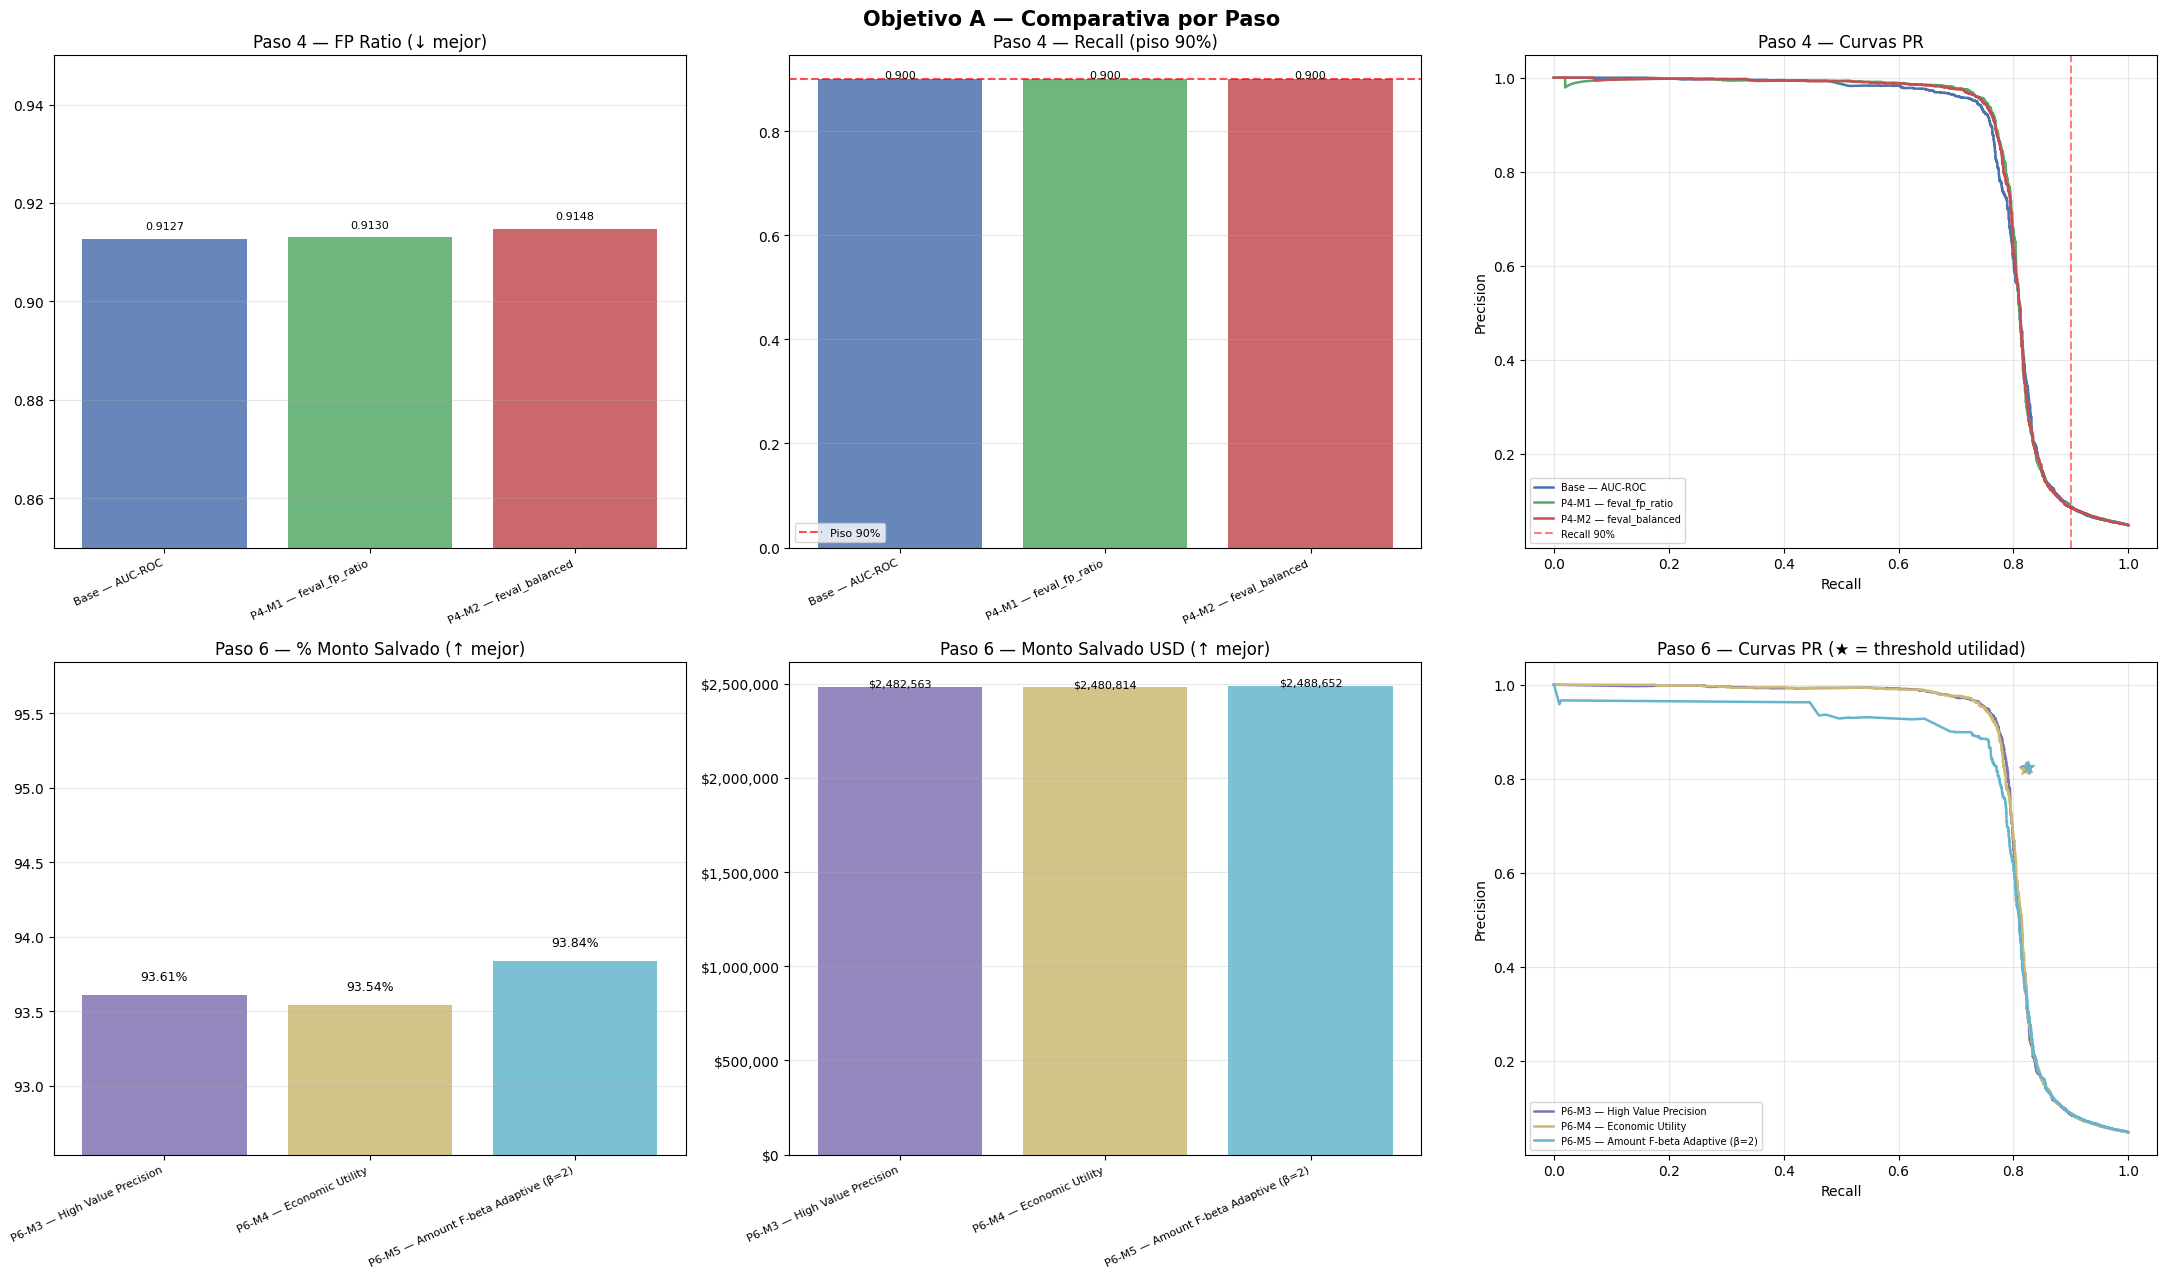

Guardado: /content/drive/MyDrive/proyecto_plus_ti/models/modelo_a/comparativa_v2.png


In [ ]:
colores_p4 = ['#4C72B0', '#55A868', '#C44E52']
colores_p6 = ['#8172B2', '#CCB974', '#64B5CD']

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Objetivo A — Comparativa por Paso', fontsize=15, fontweight='bold')

# ── Fila 0: Paso 4 ─────────────────────────────────────────────────────────────
modelos_p4 = df_p4.index.tolist()
x4 = np.arange(len(modelos_p4))

# FP Ratio P4
ax = axes[0, 0]
bars = ax.bar(x4, df_p4['FP Ratio'].values, color=colores_p4, alpha=0.85)
ax.set_xticks(x4); ax.set_xticklabels(modelos_p4, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 4 — FP Ratio (↓ mejor)')
for b, v in zip(bars, df_p4['FP Ratio'].values):
    ax.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.4f}', ha='center', fontsize=8)
ax.set_ylim(0.85, 0.95); ax.grid(axis='y', alpha=0.3)

# Recall P4
ax = axes[0, 1]
bars = ax.bar(x4, df_p4['Recall'].values, color=colores_p4, alpha=0.85)
ax.axhline(0.90, color='red', linestyle='--', alpha=0.7, label='Piso 90%')
ax.set_xticks(x4); ax.set_xticklabels(modelos_p4, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 4 — Recall (piso 90%)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, df_p4['Recall'].values):
    ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.3f}', ha='center', fontsize=8)

# Curvas PR P4
ax = axes[0, 2]
for prob, label, color in zip(
    [prob_base, prob_fp, prob_bal], modelos_p4, colores_p4
):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, label=label, color=color, linewidth=1.8)
ax.axvline(0.90, color='red', linestyle='--', alpha=0.5, label='Recall 90%')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Paso 4 — Curvas PR'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Fila 1: Paso 6 ─────────────────────────────────────────────────────────────
modelos_p6 = df_p6.index.tolist()
x6 = np.arange(len(modelos_p6))

# % Monto Salvado P6
ax = axes[1, 0]
bars = ax.bar(x6, df_p6['% Monto Salvado'].values, color=colores_p6, alpha=0.85)
ax.set_xticks(x6); ax.set_xticklabels(modelos_p6, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 6 — % Monto Salvado (↑ mejor)')
for b, v in zip(bars, df_p6['% Monto Salvado'].values):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.2f}%', ha='center', fontsize=9)
ax.set_ylim(
    df_p6['% Monto Salvado'].min() - 1,
    min(df_p6['% Monto Salvado'].max() + 2, 100)
)
ax.grid(axis='y', alpha=0.3)

# Monto Salvado USD absoluto P6
ax = axes[1, 1]
salvado_vals = df_p6['Monto Salvado USD'].values
bars = ax.bar(x6, salvado_vals, color=colores_p6, alpha=0.85)
ax.set_xticks(x6); ax.set_xticklabels(modelos_p6, rotation=25, ha='right', fontsize=8)
ax.set_title('Paso 6 — Monto Salvado USD (↑ mejor)')
for b, v in zip(bars, salvado_vals):
    ax.text(b.get_x()+b.get_width()/2, v+1000, f'${v:,.0f}', ha='center', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

# Curvas PR P6
ax = axes[1, 2]
for prob, label, color in zip(
    [prob_hv, prob_eu, prob_afb], modelos_p6, colores_p6
):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, label=label, color=color, linewidth=1.8)
# Marcar el threshold de utilidad de cada modelo
for prob, thr, color in zip(
    [prob_hv, prob_eu, prob_afb],
    [thr_hv, thr_eu, thr_afb],
    colores_p6
):
    y_pred_t = (prob >= thr).astype(int)
    p_val = y_pred_t[y_test.values == 1].mean() if y_pred_t.sum() > 0 else 0
    r_val = (y_pred_t * (y_test.values == 1)).sum() / (y_test.values == 1).sum()
    ax.scatter([r_val], [p_val], color=color, s=80, zorder=5, marker='*')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Paso 6 — Curvas PR (★ = threshold utilidad)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_OUTPUTS}/comparativa_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardado: {PATH_OUTPUTS}/comparativa_v2.png')

### Feature importance — modelos P6

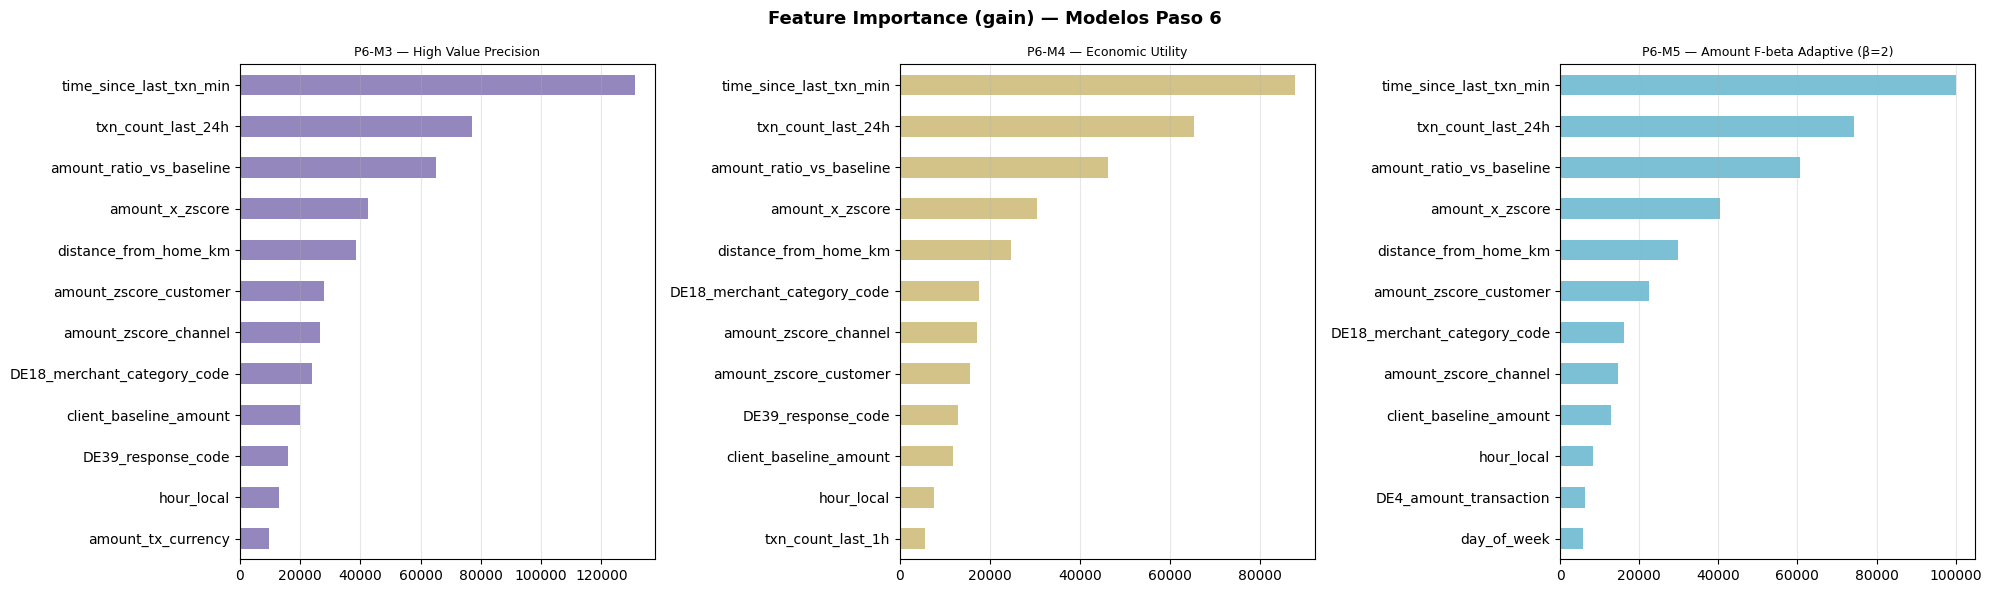

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Feature Importance (gain) — Modelos Paso 6', fontsize=13, fontweight='bold')

for ax, model, name, color in zip(
    axes,
    [model_hv, model_eu, model_afb],
    modelos_p6,
    colores_p6
):
    fi = pd.Series(
        model.feature_importance(importance_type='gain'),
        index=FEATURES
    ).sort_values(ascending=True).tail(12)
    fi.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(name, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATH_OUTPUTS}/feature_importance_p6.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 9. Conclusión y selección de función feval

## Paso 4 (punto común)
**Criterio:** menor FP ratio con recall ≥ 90%.

In [ ]:
# ── Paso 4: selección ─────────────────────────────────────────────────────────
cand_p4 = df_p4[df_p4['Recall'] >= 0.90].copy()

if len(cand_p4):
    mejor_p4 = cand_p4['FP Ratio'].idxmin()
    print('Paso 4 — modelos con recall ≥ 90%:')
    print(cand_p4[['Recall','FP Ratio','FP','% Monto Salvado']].to_string())
    print(f'\n→ Seleccionado: {mejor_p4}')
    print(f'  FP Ratio : {cand_p4.loc[mejor_p4, "FP Ratio"]:.4f}')
    print(f'  Recall   : {cand_p4.loc[mejor_p4, "Recall"]:.2%}')
    print(f'  FP       : {int(cand_p4.loc[mejor_p4, "FP"]):,}')
else:
    print('⚠ Ningún modelo alcanzó recall ≥ 90%. Revisar parámetros.')

Paso 4 — modelos con recall ≥ 90%:
                        Recall  FP Ratio     FP  % Monto Salvado
Modelo                                                          
Base — AUC-ROC          0.9004    0.9127  22495            96.46
P4-M1 — feval_fp_ratio  0.9004    0.9130  22569            96.47
P4-M2 — feval_balanced  0.9004    0.9148  23095            96.60

→ Seleccionado: Base — AUC-ROC
  FP Ratio : 0.9127
  Recall   : 90.04%
  FP       : 22,495


## Paso 6 (objetivo del grupo)
**Criterio:** mayor monto salvado en USD con threshold de utilidad máxima.

In [ ]:
# ── Paso 6: selección ─────────────────────────────────────────────────────────
mejor_p6_monto = df_p6['Monto Salvado USD'].idxmax()
mejor_p6_pct   = df_p6['% Monto Salvado'].idxmax()

print('Paso 6 — comparativa modelos:')
print(df_p6[['Threshold','Recall','FP Ratio','FP','Monto Salvado USD','% Monto Salvado']].to_string())

print(f'\n→ Mejor en USD absoluto    : {mejor_p6_monto}')
print(f'→ Mejor en % monto salvado : {mejor_p6_pct}')

mejor = mejor_p6_monto  # criterio principal del enunciado

print(f"""
CONCLUSIÓN PASO 6:
El objetivo del grupo es maximizar el monto de fraude detectado en USD.
A diferencia del Paso 4, no se impone un piso de recall del 90%;
el threshold se elige por utilidad económica máxima.

Modelo seleccionado: {mejor}
  Monto Salvado USD : ${df_p6.loc[mejor, 'Monto Salvado USD']:,.2f}
  % Monto Salvado   : {df_p6.loc[mejor, '% Monto Salvado']:.2f}%
  Recall            : {df_p6.loc[mejor, 'Recall']:.2%}  (informativo)
  FP Ratio          : {df_p6.loc[mejor, 'FP Ratio']:.4f}
  FP                : {int(df_p6.loc[mejor, 'FP']):,}
  Threshold         : {df_p6.loc[mejor, 'Threshold']}

Justificación: la función feval de este modelo guía al árbol a valorar
explícitamente el monto en USD de cada transacción durante el entrenamiento,
alineando la señal de aprendizaje con el objetivo de negocio del banco.
""")

Paso 6 — comparativa modelos:
                                      Threshold  Recall  FP Ratio    FP  Monto Salvado USD  % Monto Salvado
Modelo                                                                                                     
P6-M3 — High Value Precision             0.1480  0.8225    0.6644  3891         2482562.95            93.61
P6-M4 — Economic Utility                 0.1867  0.8208    0.6147  3129         2480813.94            93.54
P6-M5 — Amount F-beta Adaptive (β=2)     0.1833  0.8259    0.6955  4506         2488652.42            93.84

→ Mejor en USD absoluto    : P6-M5 — Amount F-beta Adaptive (β=2)
→ Mejor en % monto salvado : P6-M5 — Amount F-beta Adaptive (β=2)

CONCLUSIÓN PASO 6:
El objetivo del grupo es maximizar el monto de fraude detectado en USD.
A diferencia del Paso 4, no se impone un piso de recall del 90%;
el threshold se elige por utilidad económica máxima.

Modelo seleccionado: P6-M5 — Amount F-beta Adaptive (β=2)
  Monto Salvado USD : $2,488